In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as stats
import seaborn as sns
import numpy as np
from pathlib import Path
import os

### TODO ###
# Adjust percentile data based off of pitch type (negative HB is better for some pitches)
# Separate Left/Right handed pitchers
# Add avg. run value per pitch as a statistic?
# GUI to select pitch type and pitchers at some point
# Separate graphs for inherenent pitch qualities (spinrate, axis, movement, %usage) (ctd)
# from deterministic pitch qualities (whiff%, run value, etc.)

In [11]:
current_path = Path(os.getcwd())
total_data = pd.read_csv(current_path / "AAA Data" / "AAA_agg.csv")

In [56]:
# prompt: Create a function that generates the IOU (intersection over union) of two overlaid spider plots.

def calculate_iou(player1, player2, pitch_type):
    """
    Calculates the Intersection over Union (IoU) of two pitchers' spider plots.

    Args:
        player1: The name of the first pitcher.
        player2: The name of the second pitcher.

    Returns:
        The IoU value (float) between 0 and 1, or None if an error occurs.
    """
    
    categories = ["start_speed", "ivb", "hb", "spin_rate", "launch_angle", "whiff rate", "proportion"]

    df_player1 = pd.read_csv(current_path / "AAA Data" / (player1 + ".csv"))
    df_player2 = pd.read_csv(current_path / "AAA Data" / (player2 + ".csv"))

    df_player1 = df_player1[df_player1['pitch_type'] == pitch_type]
    df_player2 = df_player2[df_player2['pitch_type'] == pitch_type]
    total_data_filt = total_data[total_data['pitch_type'] == pitch_type].fillna(0)
    player1_percentiles = [stats.percentileofscore(total_data_filt[col], df_player1[col]) for col in categories]
    player2_percentiles = [stats.percentileofscore(total_data_filt[col], df_player2[col]) for col in categories]

    # Calculate intersection and union of percentile ranks
    intersection = 0
    union = 0
    for i in range(len(categories)):
        intersection += min(player1_percentiles[i], player2_percentiles[i])
        union += max(player1_percentiles[i], player2_percentiles[i])

    if union == 0:
        return 0  # Avoid division by zero

    iou = intersection / union
    return round(iou[0]*100,3)

In [61]:
# prompt: Create a function that takes two arguments, player 1 and player 2 from pitcher_stats. Create an overlaid radar plot using all the other features from the dataset. Instead of plotting the raw values, however, plot the PERCENTILES of each value in relation to the entire column.

def compare_pitchers(player1, player2, pitch_type):
    """
    Compares two pitchers using an overlaid radar plot of percentile ranks.

    Args:
        player1: The name of the first pitcher.
        player2: The name of the second pitcher.
    """
    categories = ["start_speed", "ivb", "hb", "spin_rate", "launch_angle", "whiff rate", "proportion"]
    N = len(categories)
    pitch_dic = {"FF": "Four-Seam Fastball", "SL": "Slider", "CH": "Changeup", "CU": "Curveball", "FC": "Cutter", "SI": "Sinker", "ST": "Sweeper", "FS": "Splitter"}
    df_player1 = pd.read_csv(current_path / "AAA Data" / (player1 + ".csv"))
    df_player2 = pd.read_csv(current_path / "AAA Data" / (player2 + ".csv"))

    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    df_player1 = df_player1[df_player1['pitch_type'] == pitch_type]
    df_player2 = df_player2[df_player2['pitch_type'] == pitch_type]
    total_data_filt = total_data[total_data['pitch_type'] == pitch_type].fillna(0)
    player1_percentiles = [stats.percentileofscore(total_data_filt[col], df_player1[col]) for col in categories]
    player2_percentiles = [stats.percentileofscore(total_data_filt[col], df_player2[col]) for col in categories]

    player1_percentiles += player1_percentiles[:1]
    player2_percentiles += player2_percentiles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    N = 800j
    rr, tt = np.mgrid[0:100:N, 0:2*np.pi:N]
    colors = rr / rr.max()
    ax.pcolormesh(tt, rr, colors, cmap=cm.coolwarm, alpha=0.2, shading='nearest', zorder=2.2)

    ax.plot(angles, player1_percentiles, linewidth=2, label=player1, color="black")
    ax.plot(angles, player2_percentiles, linewidth=2, label=player2, color="red")


    ax.fill(angles, player1_percentiles, alpha=0.25)
    ax.fill(angles, player2_percentiles, alpha=0.25)

    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_yticks(np.arange(0,101,20))
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    ax.set_title(f"{player1} and {player2}:\n {pitch_dic[pitch_type]}")
    #plt.show()
    #print(f"\nThe IOU between {player1} and {player2} is {calculate_iou(player1, player2, pitch_type)}%.")

In [23]:
player1 = "Bubba Chandler"
player2 = "Jackson Jobe"
pitches1 = pd.read_csv(current_path / "AAA Data" / (player1 + ".csv")).pitch_type.unique()
pitches2 = pd.read_csv(current_path / "AAA Data" / (player2 + ".csv")).pitch_type.unique()
print(set(pitches1).intersection(set(pitches2)))

{'SL', 'CH', 'FF'}



The IOU between Bubba Chandler and Jackson Jobe is 72.469%.


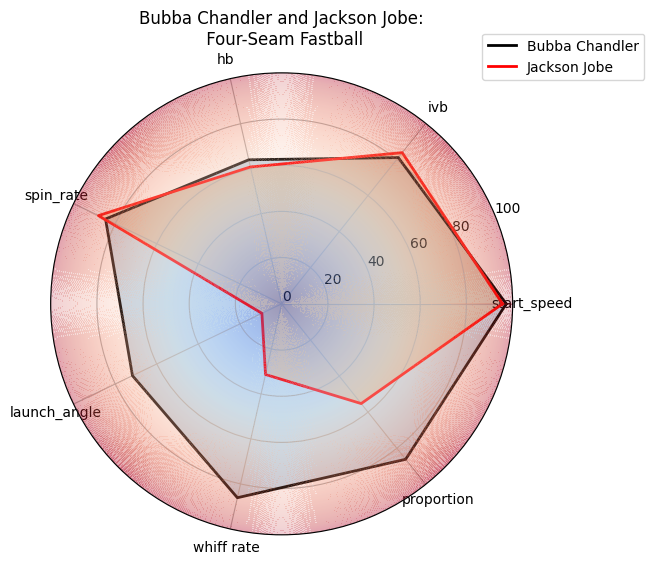

In [35]:
compare_pitchers(player1, player2, "FF")

In [59]:
import itertools
best_ious = {}
files = []
for file in Path(current_path / "AAA Data").iterdir():
	if file.name == "AAA_agg.csv" or file.name[0] == "." or file.name[-4:] != ".csv":
		continue
	files.append(file)

for p1, p2 in list(itertools.combinations(files, 2)):
	pitches1 = pd.read_csv(p1).pitch_type.dropna().unique()
	pitches2 = pd.read_csv(p2).pitch_type.dropna().unique()
	for p_type in set(pitches1).intersection(set(pitches2)):
		if p_type not in best_ious:
			best_ious[p_type] = [0, []]
		iou = calculate_iou(p1.stem, p2.stem, p_type)
		if iou > best_ious[p_type][0]:
			best_ious[p_type][0] = iou
			best_ious[p_type][1] = [p1.stem, p2.stem]

print("\nBest IOUs:")
for pitch_type, (iou, players) in best_ious.items():
	print(f"{pitch_type}: {iou}% between {players[0]} and {players[1]}")




Best IOUs:
ST: 68.133% between Jackson Jobe and Will Warren
SL: 75.397% between Richard Fitts and Bubba Chandler
CH: 73.14% between Richard Fitts and Joey Estes
FF: 83.001% between AJ Smith-Shawver and Bubba Chandler
FC: 51.376% between Joey Estes and Will Warren
CU: 37.729% between AJ Smith-Shawver and Bubba Chandler


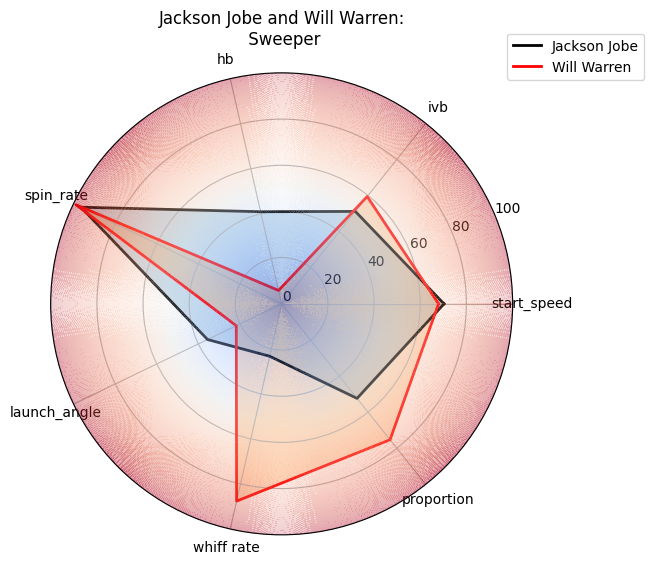

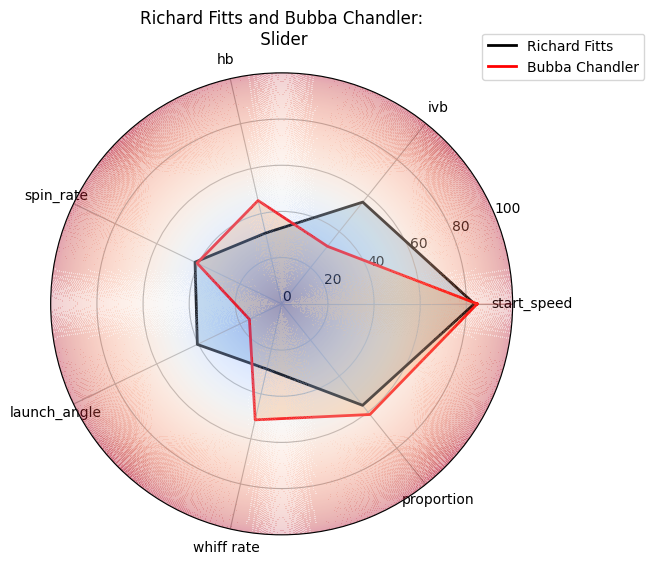

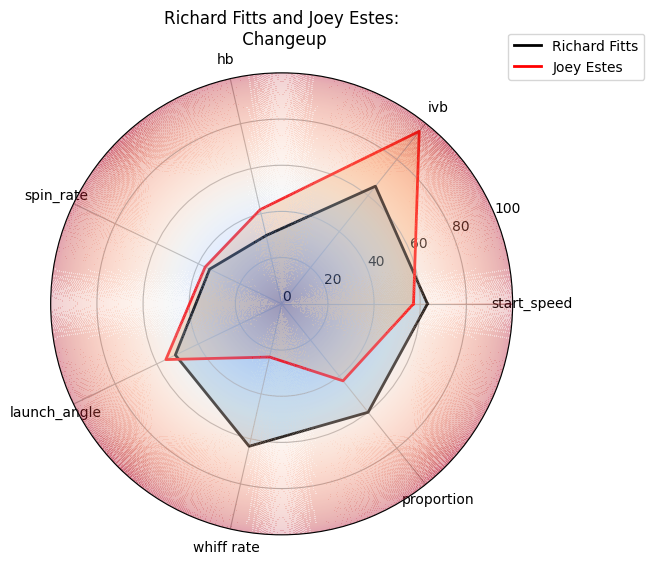

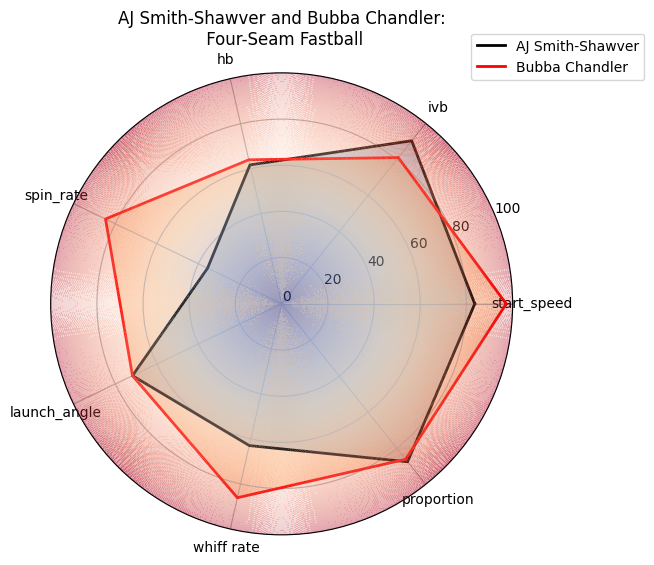

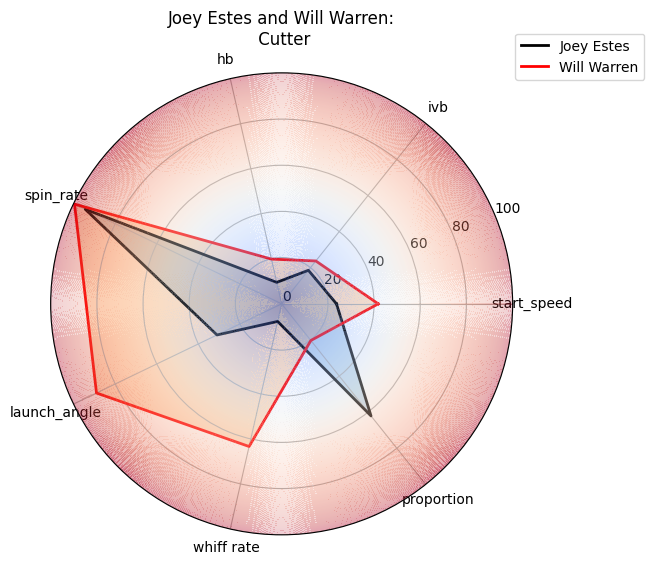

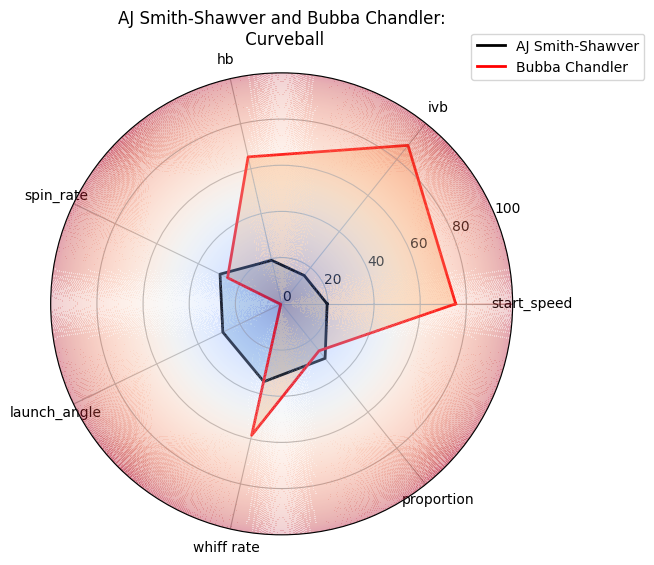

In [62]:
for p_type, (iou, players) in best_ious.items():
	compare_pitchers(players[0], players[1], p_type)